# IOU Tracker - Optuna Grid Search Analysis

This notebook analyzes the grid search results for the IOU tracker optimization.
We explore the relationship between hyperparameters (`iou_threshold`, `max_age`) and the tracking metrics (HOTA, IDF1).

In [28]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Data from Optuna Database

In [29]:
# Connect to Optuna database
DB_PATH = "../results/studies/optimization.db"
STUDY_NAME = "iou_params_study_grid_search"

conn = sqlite3.connect(DB_PATH)

# Check available studies
studies = pd.read_sql("SELECT * FROM studies;", conn)
print("Available studies:")
print(studies)
print("\n" + "="*80)

Available studies:
   study_id                    study_name
0         1             sort_params_study
1         2        bytetrack_params_study
2         4           ocsort_params_study
3         5              iou_params_study
4         6  iou_params_study_grid_search



In [30]:
# Load trials for our study
query_trials = f"""
SELECT * FROM trials 
WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
"""
df_trials = pd.read_sql(query_trials, conn)

# Load trial parameters
query_params = f"""
SELECT * FROM trial_params 
WHERE trial_id IN (
    SELECT trial_id FROM trials 
    WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
)
"""
df_params = pd.read_sql(query_params, conn)

# Load trial values (multi-objective: HOTA and IDF1)
query_values = f"""
SELECT * FROM trial_values 
WHERE trial_id IN (
    SELECT trial_id FROM trials 
    WHERE study_id = (SELECT study_id FROM studies WHERE study_name = '{STUDY_NAME}' LIMIT 1)
)
"""
df_values = pd.read_sql(query_values, conn)

conn.close()

print(f"Total trials: {len(df_trials)}")
print(f"Total parameters: {len(df_params)}")
print(f"Total values: {len(df_values)}")

Total trials: 244
Total parameters: 488
Total values: 488


## 2. Prepare Data

In [31]:
# Pivot parameters to have one column per parameter
df_params_pivot = df_params.pivot(
    index="trial_id",
    columns="param_name",
    values="param_value"
).reset_index()
df_params_pivot.columns.name = None

# Check df_values structure
print("df_values columns:", df_values.columns.tolist())
print("\ndf_values sample:")
print(df_values.head(10))

# Pivot values to have HOTA and IDF1 as separate columns
# For multi-objective, values are stored with different column names depending on Optuna version
if 'objective_id' in df_values.columns:
    # Optuna >= 3.0
    df_hota = df_values[df_values['objective_id'] == 0][['trial_id', 'value']].rename(columns={'value': 'HOTA'})
    df_idf1 = df_values[df_values['objective_id'] == 1][['trial_id', 'value']].rename(columns={'value': 'IDF1'})
else:
    # Alternative structure - group by trial_id and get first/second values
    print("\nProcessing multi-objective values without objective_id...")
    
    # Sort and group properly
    df_values_sorted = df_values.sort_values('trial_id')
    
    # For each trial_id, get the first and second value
    hota_data = []
    idf1_data = []
    
    for trial_id in df_values_sorted['trial_id'].unique():
        trial_values = df_values_sorted[df_values_sorted['trial_id'] == trial_id]['value'].values
        if len(trial_values) >= 2:
            hota_data.append({'trial_id': trial_id, 'HOTA': trial_values[0]})
            idf1_data.append({'trial_id': trial_id, 'IDF1': trial_values[1]})
    
    df_hota = pd.DataFrame(hota_data)
    df_idf1 = pd.DataFrame(idf1_data)
    
    print(f"Extracted {len(df_hota)} HOTA values and {len(df_idf1)} IDF1 values")

print("\n" + "="*80)

# Merge everything
df_results = df_params_pivot.merge(df_hota, on='trial_id').merge(df_idf1, on='trial_id')

# Convert to numeric
df_results['iou_threshold'] = pd.to_numeric(df_results['iou_threshold'])
df_results['max_age'] = pd.to_numeric(df_results['max_age'])
df_results['HOTA'] = pd.to_numeric(df_results['HOTA'])
df_results['IDF1'] = pd.to_numeric(df_results['IDF1'])

# Add combined metric
df_results['Combined'] = (df_results['HOTA'] + df_results['IDF1']) / 2

print(f"Prepared {len(df_results)} trials for analysis")
print("\nData shape:", df_results.shape)
print("\nFirst rows:")
df_results.head()

df_values columns: ['trial_value_id', 'trial_id', 'objective', 'value', 'value_type']

df_values sample:
   trial_value_id  trial_id  objective     value value_type
0            2327      1174          0  0.634822     FINITE
1            2328      1174          1  0.615911     FINITE
2            2329      1175          0  0.633140     FINITE
3            2330      1175          1  0.618328     FINITE
4            2331      1176          0  0.635477     FINITE
5            2332      1176          1  0.621098     FINITE
6            2333      1177          0  0.633662     FINITE
7            2334      1177          1  0.621982     FINITE
8            2335      1178          0  0.657440     FINITE
9            2336      1178          1  0.651870     FINITE

Processing multi-objective values without objective_id...
Extracted 244 HOTA values and 244 IDF1 values

Prepared 244 trials for analysis

Data shape: (244, 6)

First rows:


,trial_id,iou_threshold,max_age,HOTA,IDF1,Combined
0,1174,0.35,5.0,0.634822,0.615911,0.625366
1,1175,0.20,12.0,0.633140,0.618328,0.625734
2,1176,0.10,8.0,0.635477,0.621098,0.628288
3,1177,0.20,15.0,0.633662,0.621982,0.627822
4,1178,0.35,4.0,0.657440,0.651870,0.654655


## 3. Overall Statistics

In [32]:
print("="*80)
print("OVERALL STATISTICS")
print("="*80)
print("\nBest results:")
print(f"  Max HOTA: {df_results['HOTA'].max():.4f}")
print(f"  Max IDF1: {df_results['IDF1'].max():.4f}")
print(f"  Max Combined: {df_results['Combined'].max():.4f}")

print("\nBest trial (by HOTA):")
best_hota_idx = df_results['HOTA'].idxmax()
print(df_results.loc[best_hota_idx, ['iou_threshold', 'max_age', 'HOTA', 'IDF1']])

print("\nBest trial (by IDF1):")
best_idf1_idx = df_results['IDF1'].idxmax()
print(df_results.loc[best_idf1_idx, ['iou_threshold', 'max_age', 'HOTA', 'IDF1']])

print("\nBest trial (by Combined):")
best_combined_idx = df_results['Combined'].idxmax()
print(df_results.loc[best_combined_idx, ['iou_threshold', 'max_age', 'HOTA', 'IDF1', 'Combined']])

print("\nParameter ranges:")
print(f"  iou_threshold: [{df_results['iou_threshold'].min():.2f}, {df_results['iou_threshold'].max():.2f}]")
print(f"  max_age: [{df_results['max_age'].min():.0f}, {df_results['max_age'].max():.0f}]")

OVERALL STATISTICS

Best results:
  Max HOTA: 0.6588
  Max IDF1: 0.6566
  Max Combined: 0.6577

Best trial (by HOTA):
iou_threshold    0.050000
max_age          2.000000
HOTA             0.658809
IDF1             0.656645
Name: 66, dtype: float64

Best trial (by IDF1):
iou_threshold    0.050000
max_age          2.000000
HOTA             0.658809
IDF1             0.656645
Name: 66, dtype: float64

Best trial (by Combined):
iou_threshold    0.050000
max_age          2.000000
HOTA             0.658809
IDF1             0.656645
Combined         0.657727
Name: 66, dtype: float64

Parameter ranges:
  iou_threshold: [0.00, 0.75]
  max_age: [1, 15]


## 4. Pareto Front Analysis

In [33]:
# Identify Pareto optimal trials
def is_pareto_optimal(costs):
    """
    Find the pareto-optimal points (for maximization)
    :param costs: An (n_points, n_costs) array
    :return: A boolean array indicating pareto optimality
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # Keep any point with a higher value in at least one dimension
            is_efficient[is_efficient] = np.any(costs[is_efficient] >= c, axis=1)
            is_efficient[i] = True
    return is_efficient

# Get Pareto front
costs = df_results[['HOTA', 'IDF1']].values
pareto_mask = is_pareto_optimal(costs)
df_results['is_pareto'] = pareto_mask

pareto_trials = df_results[df_results['is_pareto']]
print(f"\nPareto front contains {len(pareto_trials)} trials")
print("\nPareto optimal trials:")
print(pareto_trials[['trial_id', 'iou_threshold', 'max_age', 'HOTA', 'IDF1']].sort_values('HOTA', ascending=False))


Pareto front contains 1 trials

Pareto optimal trials:
    trial_id  iou_threshold  max_age      HOTA      IDF1
66      1240           0.05      2.0  0.658809  0.656645


## 5. 2D Pareto Front Visualization

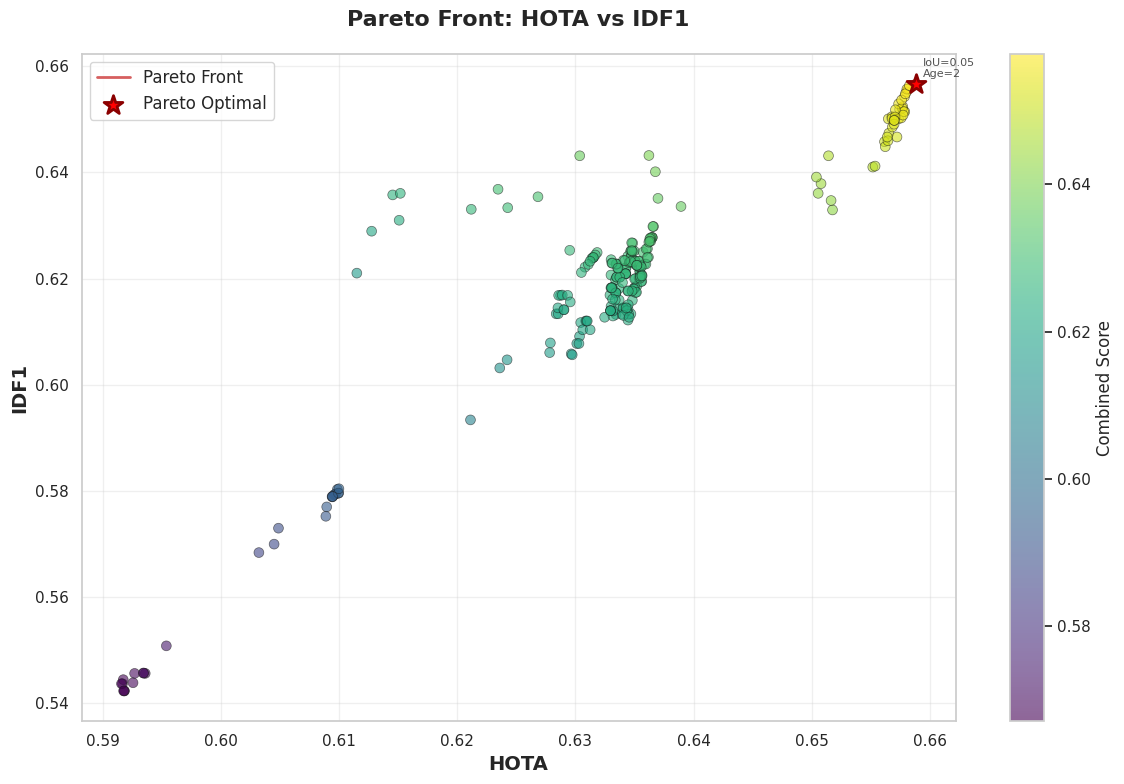

In [34]:
fig, ax = plt.subplots(figsize=(12, 8))

# Plot all trials
scatter = ax.scatter(df_results['HOTA'], df_results['IDF1'], 
                    c=df_results['Combined'], cmap='viridis', 
                    s=50, alpha=0.6, edgecolors='k', linewidth=0.5)

# Highlight Pareto front
pareto_sorted = pareto_trials.sort_values('HOTA')
ax.plot(pareto_sorted['HOTA'], pareto_sorted['IDF1'], 
        'r-', linewidth=2, label='Pareto Front', zorder=5)
ax.scatter(pareto_trials['HOTA'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', 
          linewidth=2, label='Pareto Optimal', zorder=6)

# Annotate best trials
for idx, row in pareto_trials.iterrows():
    ax.annotate(f"IoU={row['iou_threshold']:.2f}\nAge={row['max_age']:.0f}", 
                xy=(row['HOTA'], row['IDF1']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8)

ax.set_xlabel('HOTA', fontsize=14, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=14, fontweight='bold')
ax.set_title('Pareto Front: HOTA vs IDF1', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Combined Score', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Interactive 3D Scatter Plot - Pareto Front

In [35]:
# Create interactive 3D plot with Plotly
df_results['Pareto'] = df_results['is_pareto'].map({True: 'Pareto Optimal', False: 'Regular'})

fig = go.Figure()

# Regular trials
regular = df_results[~df_results['is_pareto']]
fig.add_trace(go.Scatter3d(
    x=regular['iou_threshold'],
    y=regular['max_age'],
    z=regular['HOTA'],
    mode='markers',
    name='Regular (HOTA)',
    marker=dict(
        size=5,
        color=regular['HOTA'],
        colorscale='Blues',
        opacity=0.6,
        showscale=True,
        colorbar=dict(x=1.15, title="HOTA")
    ),
    text=[f"IoU: {row['iou_threshold']:.2f}<br>Age: {row['max_age']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in regular.iterrows()],
    hoverinfo='text'
))

# Pareto optimal trials
fig.add_trace(go.Scatter3d(
    x=pareto_trials['iou_threshold'],
    y=pareto_trials['max_age'],
    z=pareto_trials['HOTA'],
    mode='markers',
    name='Pareto Optimal (HOTA)',
    marker=dict(
        size=10,
        color='red',
        symbol='diamond',
        line=dict(color='darkred', width=2)
    ),
    text=[f"IoU: {row['iou_threshold']:.2f}<br>Age: {row['max_age']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in pareto_trials.iterrows()],
    hoverinfo='text'
))

fig.update_layout(
    title='3D Visualization: iou_threshold vs max_age vs HOTA (Pareto Front)',
    scene=dict(
        xaxis_title='IOU Threshold',
        yaxis_title='Max Age',
        zaxis_title='HOTA',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))
    ),
    width=1000,
    height=800
)

fig.show()

In [36]:
# Same for IDF1
fig2 = go.Figure()

# Regular trials
fig2.add_trace(go.Scatter3d(
    x=regular['iou_threshold'],
    y=regular['max_age'],
    z=regular['IDF1'],
    mode='markers',
    name='Regular (IDF1)',
    marker=dict(
        size=5,
        color=regular['IDF1'],
        colorscale='Greens',
        opacity=0.6,
        showscale=True,
        colorbar=dict(x=1.15, title="IDF1")
    ),
    text=[f"IoU: {row['iou_threshold']:.2f}<br>Age: {row['max_age']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in regular.iterrows()],
    hoverinfo='text'
))

# Pareto optimal trials
fig2.add_trace(go.Scatter3d(
    x=pareto_trials['iou_threshold'],
    y=pareto_trials['max_age'],
    z=pareto_trials['IDF1'],
    mode='markers',
    name='Pareto Optimal (IDF1)',
    marker=dict(
        size=10,
        color='red',
        symbol='diamond',
        line=dict(color='darkred', width=2)
    ),
    text=[f"IoU: {row['iou_threshold']:.2f}<br>Age: {row['max_age']}<br>HOTA: {row['HOTA']:.4f}<br>IDF1: {row['IDF1']:.4f}" 
          for _, row in pareto_trials.iterrows()],
    hoverinfo='text'
))

fig2.update_layout(
    title='3D Visualization: iou_threshold vs max_age vs IDF1 (Pareto Front)',
    scene=dict(
        xaxis_title='IOU Threshold',
        yaxis_title='Max Age',
        zaxis_title='IDF1',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.3))
    ),
    width=1000,
    height=800
)

fig2.show()

## 7. Hyperparameter vs Metrics Analysis

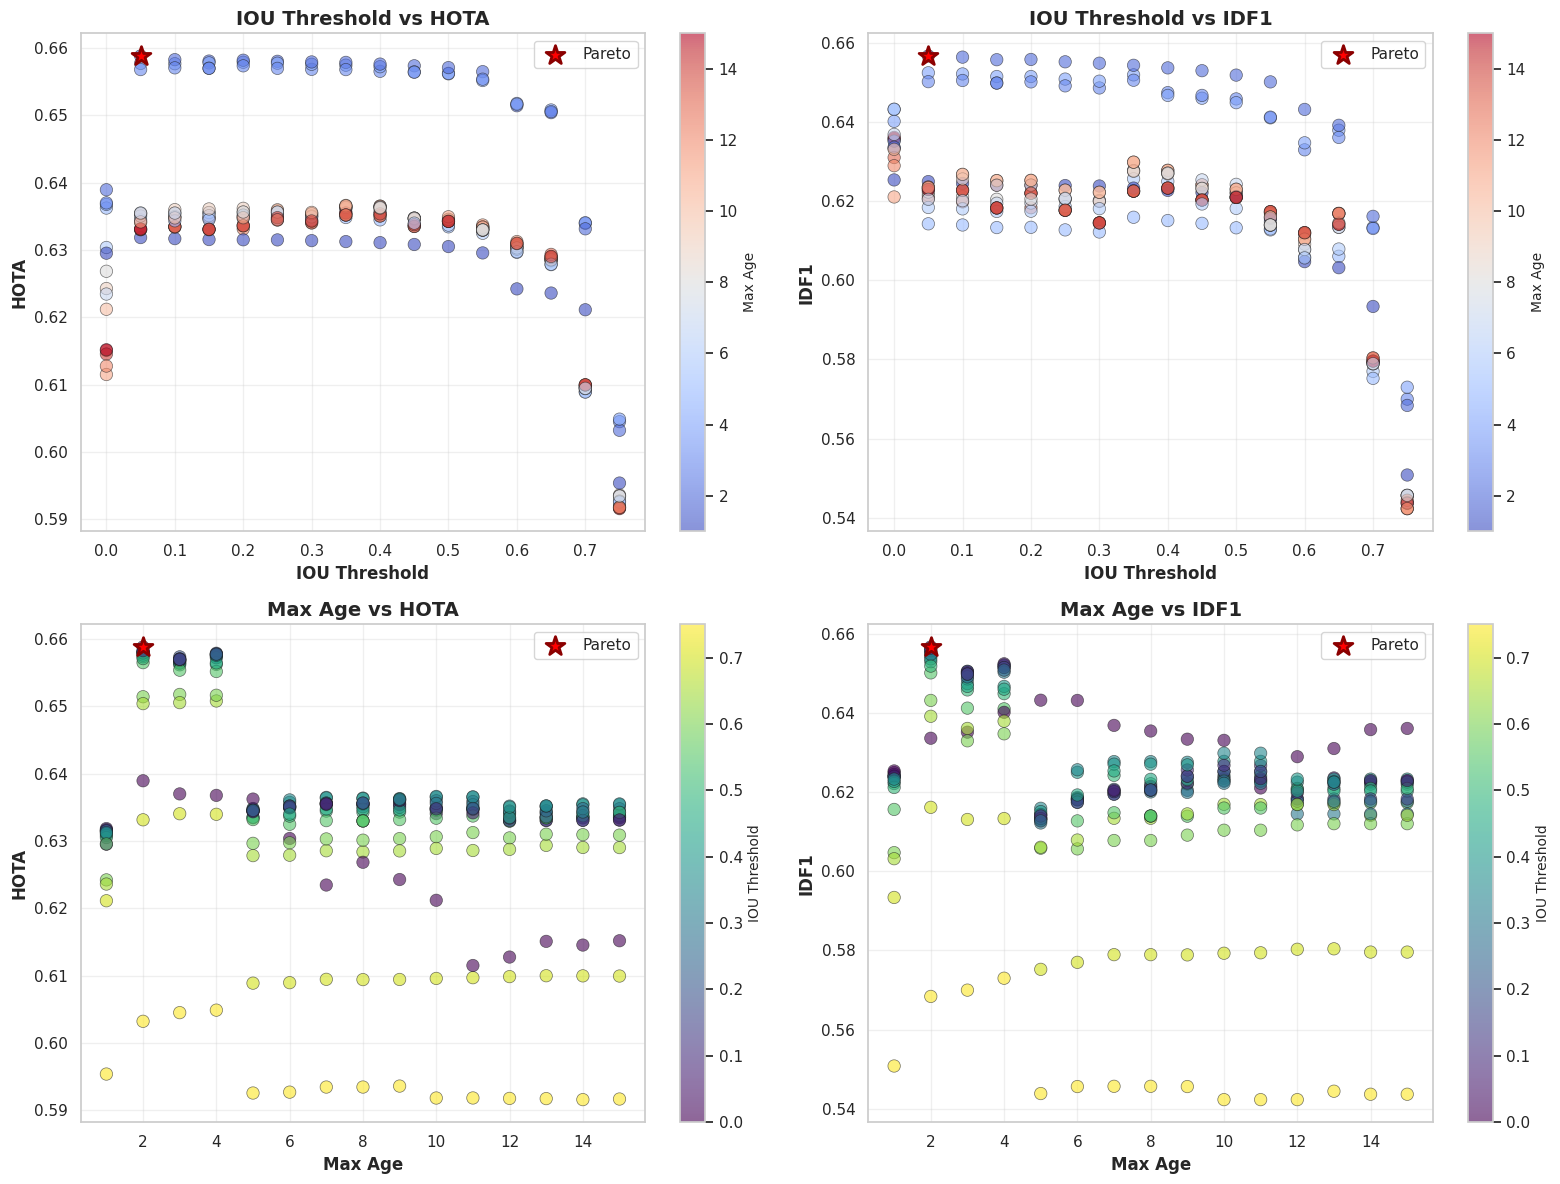

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# IOU Threshold vs HOTA
ax = axes[0, 0]
scatter = ax.scatter(df_results['iou_threshold'], df_results['HOTA'], 
                    c=df_results['max_age'], cmap='coolwarm', 
                    s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['iou_threshold'], pareto_trials['HOTA'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('IOU Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA', fontsize=12, fontweight='bold')
ax.set_title('IOU Threshold vs HOTA', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Max Age', fontsize=10)

# IOU Threshold vs IDF1
ax = axes[0, 1]
scatter = ax.scatter(df_results['iou_threshold'], df_results['IDF1'], 
                    c=df_results['max_age'], cmap='coolwarm', 
                    s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['iou_threshold'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('IOU Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('IOU Threshold vs IDF1', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Max Age', fontsize=10)

# Max Age vs HOTA
ax = axes[1, 0]
scatter = ax.scatter(df_results['max_age'], df_results['HOTA'], 
                    c=df_results['iou_threshold'], cmap='viridis', 
                    s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['max_age'], pareto_trials['HOTA'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Max Age', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA', fontsize=12, fontweight='bold')
ax.set_title('Max Age vs HOTA', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('IOU Threshold', fontsize=10)

# Max Age vs IDF1
ax = axes[1, 1]
scatter = ax.scatter(df_results['max_age'], df_results['IDF1'], 
                    c=df_results['iou_threshold'], cmap='viridis', 
                    s=80, alpha=0.6, edgecolors='k', linewidth=0.5)
ax.scatter(pareto_trials['max_age'], pareto_trials['IDF1'], 
          c='red', s=200, marker='*', edgecolors='darkred', linewidth=2, label='Pareto')
ax.set_xlabel('Max Age', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1', fontsize=12, fontweight='bold')
ax.set_title('Max Age vs IDF1', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('IOU Threshold', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Heatmaps: Grid Search Results

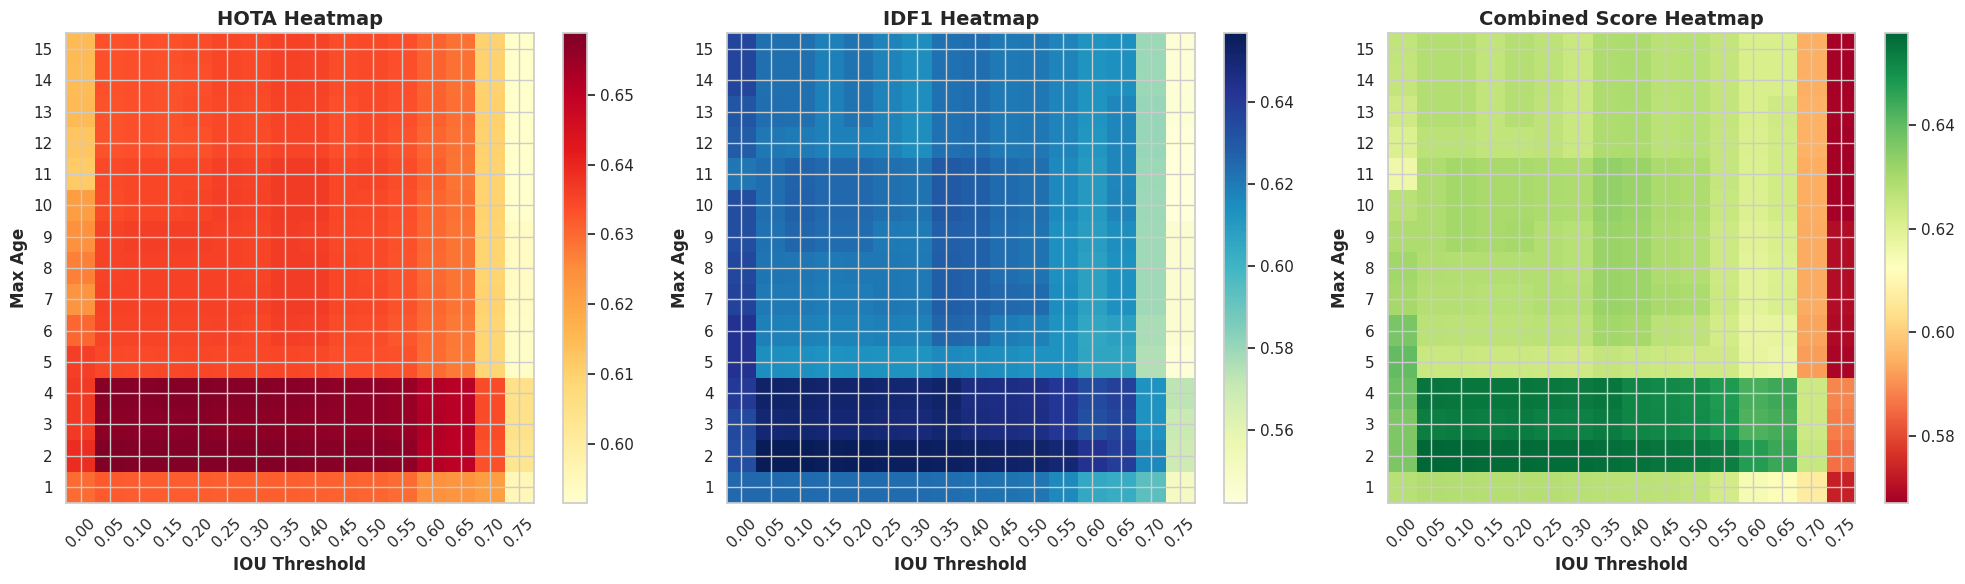

In [38]:
# Create pivot tables for heatmaps
pivot_hota = df_results.pivot_table(
    index='max_age', 
    columns='iou_threshold', 
    values='HOTA', 
    aggfunc='mean'
)

pivot_idf1 = df_results.pivot_table(
    index='max_age', 
    columns='iou_threshold', 
    values='IDF1', 
    aggfunc='mean'
)

pivot_combined = df_results.pivot_table(
    index='max_age', 
    columns='iou_threshold', 
    values='Combined', 
    aggfunc='mean'
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# HOTA Heatmap
im1 = axes[0].imshow(pivot_hota, cmap='YlOrRd', aspect='auto', origin='lower')
axes[0].set_xticks(range(len(pivot_hota.columns)))
axes[0].set_xticklabels([f'{x:.2f}' for x in pivot_hota.columns], rotation=45)
axes[0].set_yticks(range(len(pivot_hota.index)))
axes[0].set_yticklabels([f'{int(y)}' for y in pivot_hota.index])
axes[0].set_xlabel('IOU Threshold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Max Age', fontsize=12, fontweight='bold')
axes[0].set_title('HOTA Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# IDF1 Heatmap
im2 = axes[1].imshow(pivot_idf1, cmap='YlGnBu', aspect='auto', origin='lower')
axes[1].set_xticks(range(len(pivot_idf1.columns)))
axes[1].set_xticklabels([f'{x:.2f}' for x in pivot_idf1.columns], rotation=45)
axes[1].set_yticks(range(len(pivot_idf1.index)))
axes[1].set_yticklabels([f'{int(y)}' for y in pivot_idf1.index])
axes[1].set_xlabel('IOU Threshold', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Max Age', fontsize=12, fontweight='bold')
axes[1].set_title('IDF1 Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1])

# Combined Heatmap
im3 = axes[2].imshow(pivot_combined, cmap='RdYlGn', aspect='auto', origin='lower')
axes[2].set_xticks(range(len(pivot_combined.columns)))
axes[2].set_xticklabels([f'{x:.2f}' for x in pivot_combined.columns], rotation=45)
axes[2].set_yticks(range(len(pivot_combined.index)))
axes[2].set_yticklabels([f'{int(y)}' for y in pivot_combined.index])
axes[2].set_xlabel('IOU Threshold', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Max Age', fontsize=12, fontweight='bold')
axes[2].set_title('Combined Score Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

## 9. Interactive Heatmaps with Plotly

In [39]:
# Interactive heatmap for HOTA
fig = go.Figure(data=go.Heatmap(
    z=pivot_hota.values,
    x=[f'{x:.2f}' for x in pivot_hota.columns],
    y=[f'{int(y)}' for y in pivot_hota.index],
    colorscale='YlOrRd',
    text=pivot_hota.values,
    texttemplate='%{text:.4f}',
    textfont={"size": 8},
    colorbar=dict(title="HOTA")
))

fig.update_layout(
    title='HOTA - Interactive Heatmap',
    xaxis_title='IOU Threshold',
    yaxis_title='Max Age',
    width=900,
    height=600
)

fig.show()

In [40]:
# Interactive heatmap for IDF1
fig = go.Figure(data=go.Heatmap(
    z=pivot_idf1.values,
    x=[f'{x:.2f}' for x in pivot_idf1.columns],
    y=[f'{int(y)}' for y in pivot_idf1.index],
    colorscale='YlGnBu',
    text=pivot_idf1.values,
    texttemplate='%{text:.4f}',
    textfont={"size": 8},
    colorbar=dict(title="IDF1")
))

fig.update_layout(
    title='IDF1 - Interactive Heatmap',
    xaxis_title='IOU Threshold',
    yaxis_title='Max Age',
    width=900,
    height=600
)

fig.show()

## 10. Correlation Analysis

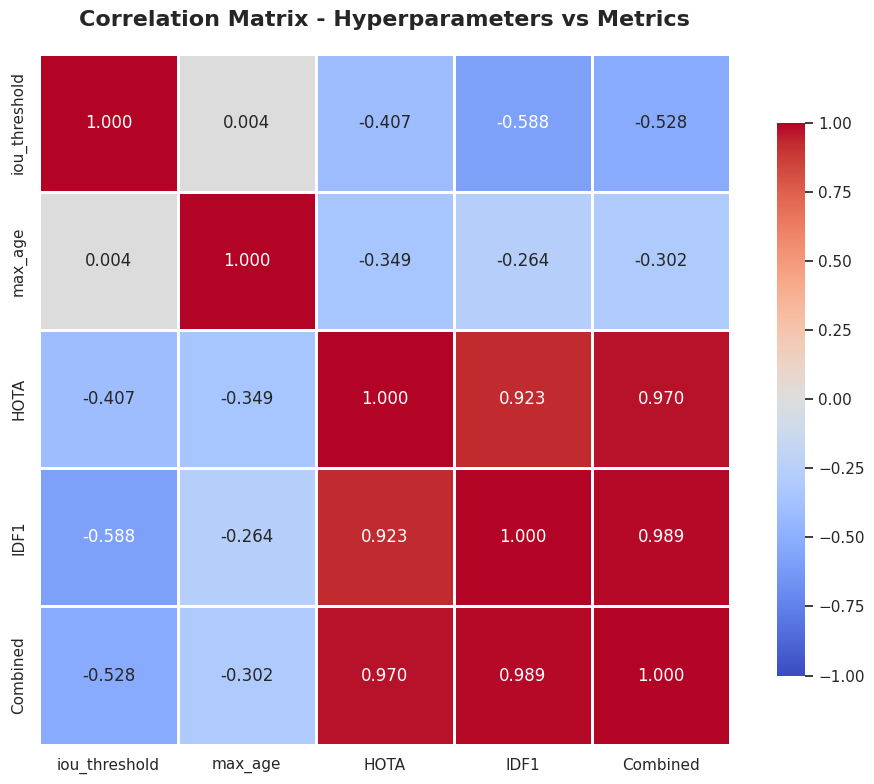


Key correlations:
  iou_threshold vs HOTA: -0.4071
  iou_threshold vs IDF1: -0.5880
  max_age vs HOTA: -0.3486
  max_age vs IDF1: -0.2643
  HOTA vs IDF1: 0.9230


In [41]:
# Correlation matrix
correlation_cols = ['iou_threshold', 'max_age', 'HOTA', 'IDF1', 'Combined']
correlation_matrix = df_results[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Correlation Matrix - Hyperparameters vs Metrics', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nKey correlations:")
print(f"  iou_threshold vs HOTA: {correlation_matrix.loc['iou_threshold', 'HOTA']:.4f}")
print(f"  iou_threshold vs IDF1: {correlation_matrix.loc['iou_threshold', 'IDF1']:.4f}")
print(f"  max_age vs HOTA: {correlation_matrix.loc['max_age', 'HOTA']:.4f}")
print(f"  max_age vs IDF1: {correlation_matrix.loc['max_age', 'IDF1']:.4f}")
print(f"  HOTA vs IDF1: {correlation_matrix.loc['HOTA', 'IDF1']:.4f}")

## 11. Distribution Analysis

/tmp/ipykernel_106821/2891318047.py:25: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



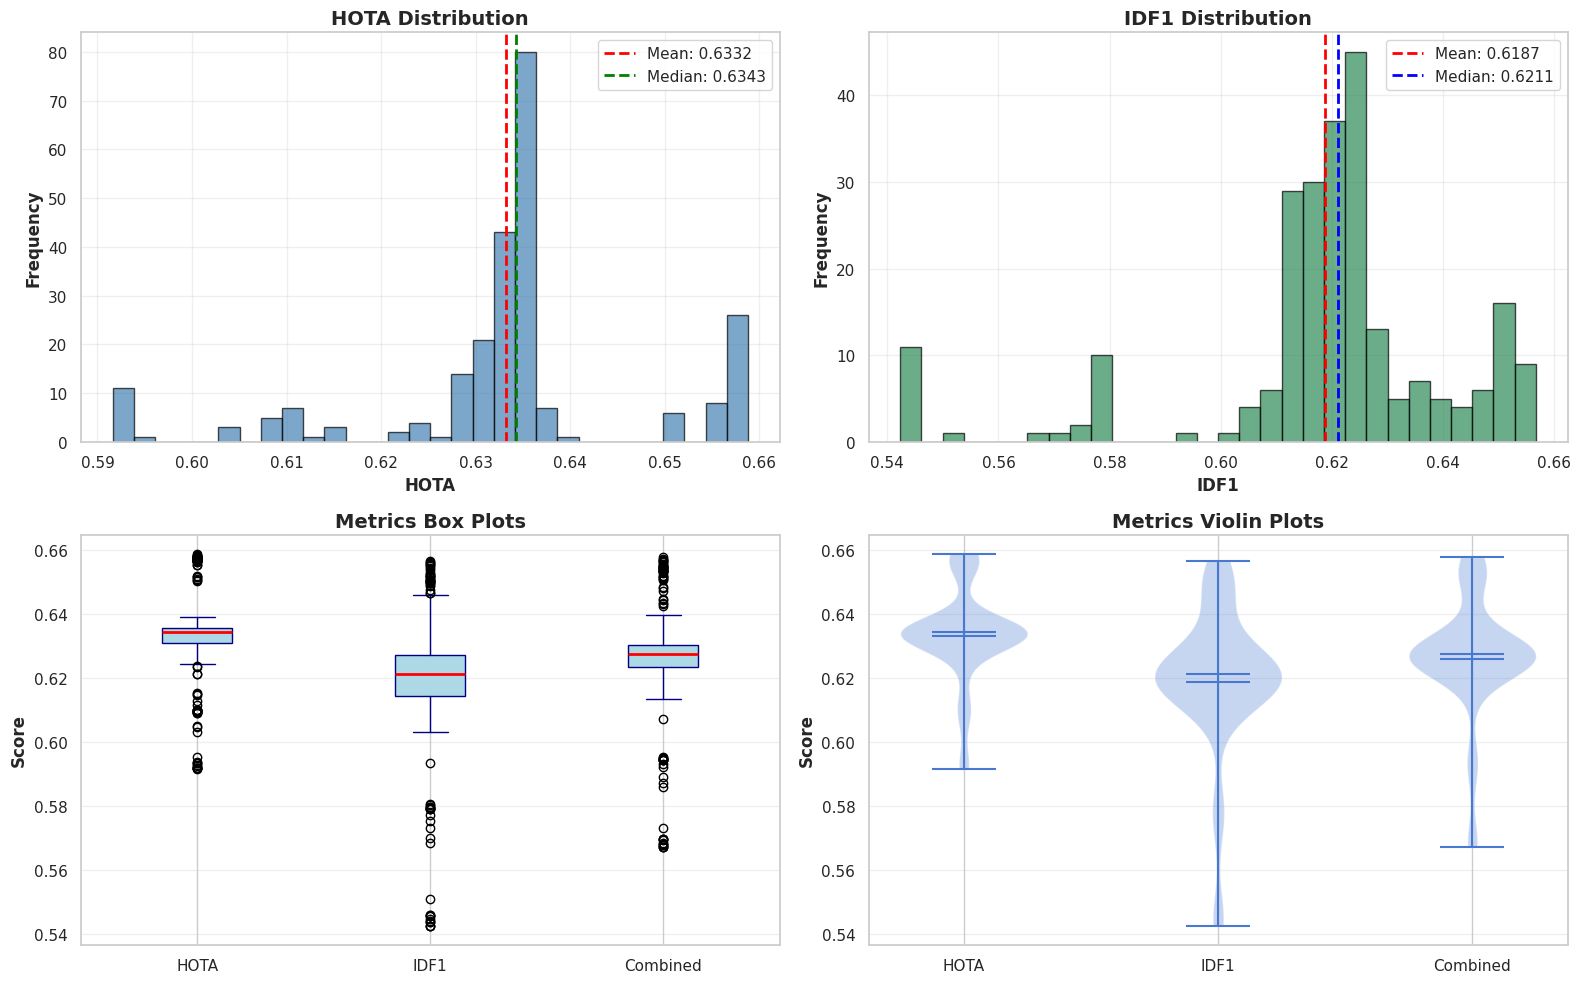

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# HOTA distribution
axes[0, 0].hist(df_results['HOTA'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df_results['HOTA'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_results["HOTA"].mean():.4f}')
axes[0, 0].axvline(df_results['HOTA'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_results["HOTA"].median():.4f}')
axes[0, 0].set_xlabel('HOTA', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('HOTA Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# IDF1 distribution
axes[0, 1].hist(df_results['IDF1'], bins=30, edgecolor='black', alpha=0.7, color='seagreen')
axes[0, 1].axvline(df_results['IDF1'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_results["IDF1"].mean():.4f}')
axes[0, 1].axvline(df_results['IDF1'].median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {df_results["IDF1"].median():.4f}')
axes[0, 1].set_xlabel('IDF1', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('IDF1 Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Box plots
box_data = [df_results['HOTA'], df_results['IDF1'], df_results['Combined']]
axes[1, 0].boxplot(box_data, labels=['HOTA', 'IDF1', 'Combined'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='navy'),
                   capprops=dict(color='navy'))
axes[1, 0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Metrics Box Plots', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Violin plots
parts = axes[1, 1].violinplot(box_data, positions=[1, 2, 3], showmeans=True, showmedians=True)
axes[1, 1].set_xticks([1, 2, 3])
axes[1, 1].set_xticklabels(['HOTA', 'IDF1', 'Combined'])
axes[1, 1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Metrics Violin Plots', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 12. Parameter Importance Analysis

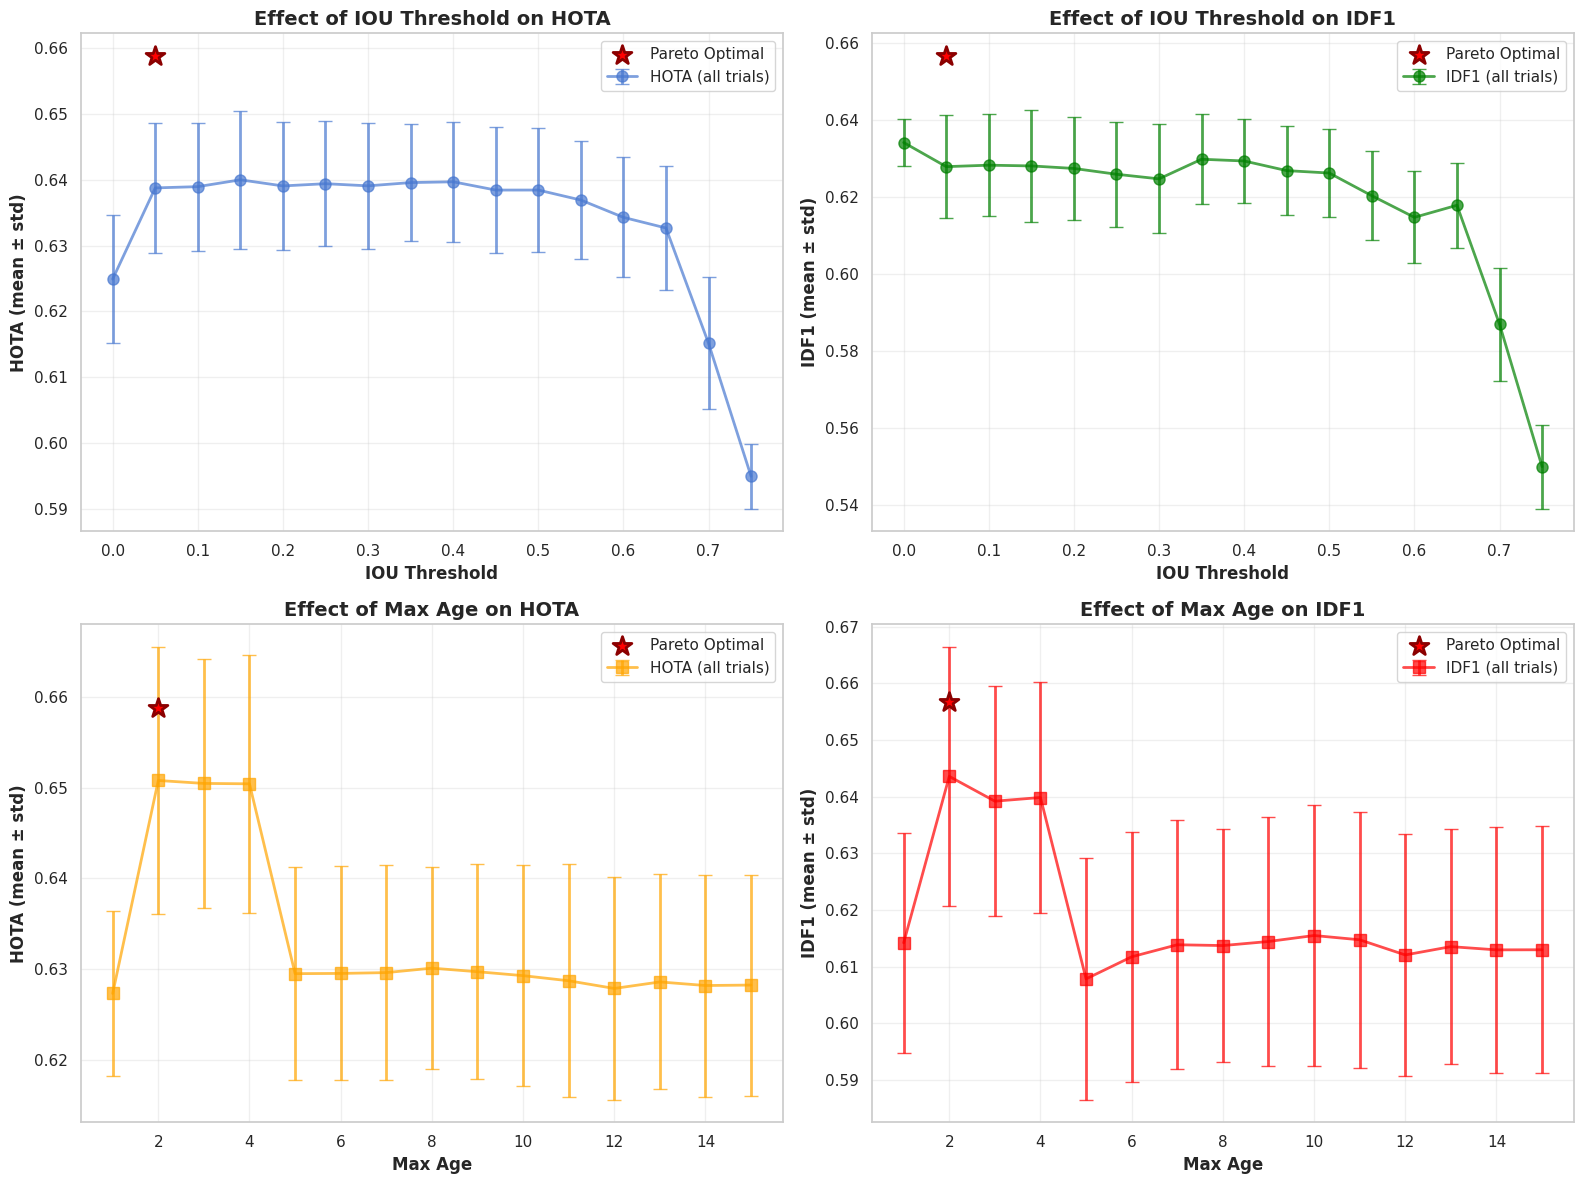

In [43]:
# Group by each parameter and calculate mean metrics
iou_grouped = df_results.groupby('iou_threshold')[['HOTA', 'IDF1', 'Combined']].agg(['mean', 'std'])
age_grouped = df_results.groupby('max_age')[['HOTA', 'IDF1', 'Combined']].agg(['mean', 'std'])

# Also group Pareto trials for overlay
pareto_iou_grouped = pareto_trials.groupby('iou_threshold')[['HOTA', 'IDF1']].mean()
pareto_age_grouped = pareto_trials.groupby('max_age')[['HOTA', 'IDF1']].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# IOU Threshold effect on HOTA
ax = axes[0, 0]
ax.errorbar(iou_grouped.index, iou_grouped['HOTA']['mean'], 
            yerr=iou_grouped['HOTA']['std'], fmt='o-', linewidth=2, 
            markersize=8, capsize=5, label='HOTA (all trials)', alpha=0.7)
# Add Pareto points
if len(pareto_iou_grouped) > 0:
    ax.scatter(pareto_iou_grouped.index, pareto_iou_grouped['HOTA'], 
              c='red', s=200, marker='*', edgecolors='darkred', 
              linewidth=2, label='Pareto Optimal', zorder=5)
ax.set_xlabel('IOU Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA (mean ± std)', fontsize=12, fontweight='bold')
ax.set_title('Effect of IOU Threshold on HOTA', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# IOU Threshold effect on IDF1
ax = axes[0, 1]
ax.errorbar(iou_grouped.index, iou_grouped['IDF1']['mean'], 
            yerr=iou_grouped['IDF1']['std'], fmt='o-', linewidth=2, 
            markersize=8, capsize=5, color='green', label='IDF1 (all trials)', alpha=0.7)
# Add Pareto points
if len(pareto_iou_grouped) > 0:
    ax.scatter(pareto_iou_grouped.index, pareto_iou_grouped['IDF1'], 
              c='red', s=200, marker='*', edgecolors='darkred', 
              linewidth=2, label='Pareto Optimal', zorder=5)
ax.set_xlabel('IOU Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1 (mean ± std)', fontsize=12, fontweight='bold')
ax.set_title('Effect of IOU Threshold on IDF1', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Max Age effect on HOTA
ax = axes[1, 0]
ax.errorbar(age_grouped.index, age_grouped['HOTA']['mean'], 
            yerr=age_grouped['HOTA']['std'], fmt='s-', linewidth=2, 
            markersize=8, capsize=5, color='orange', label='HOTA (all trials)', alpha=0.7)
# Add Pareto points
if len(pareto_age_grouped) > 0:
    ax.scatter(pareto_age_grouped.index, pareto_age_grouped['HOTA'], 
              c='red', s=200, marker='*', edgecolors='darkred', 
              linewidth=2, label='Pareto Optimal', zorder=5)
ax.set_xlabel('Max Age', fontsize=12, fontweight='bold')
ax.set_ylabel('HOTA (mean ± std)', fontsize=12, fontweight='bold')
ax.set_title('Effect of Max Age on HOTA', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Max Age effect on IDF1
ax = axes[1, 1]
ax.errorbar(age_grouped.index, age_grouped['IDF1']['mean'], 
            yerr=age_grouped['IDF1']['std'], fmt='s-', linewidth=2, 
            markersize=8, capsize=5, color='red', label='IDF1 (all trials)', alpha=0.7)
# Add Pareto points
if len(pareto_age_grouped) > 0:
    ax.scatter(pareto_age_grouped.index, pareto_age_grouped['IDF1'], 
              c='red', s=200, marker='*', edgecolors='darkred', 
              linewidth=2, label='Pareto Optimal', zorder=5)
ax.set_xlabel('Max Age', fontsize=12, fontweight='bold')
ax.set_ylabel('IDF1 (mean ± std)', fontsize=12, fontweight='bold')
ax.set_title('Effect of Max Age on IDF1', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## 13. Variance and Sensitivity Analysis

In [44]:
# Calculate variance explained by each parameter
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df_results[['iou_threshold', 'max_age']].values
y_hota = df_results['HOTA'].values
y_idf1 = df_results['IDF1'].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate partial correlations / importance
iou_range = df_results['iou_threshold'].max() - df_results['iou_threshold'].min()
age_range = df_results['max_age'].max() - df_results['max_age'].min()

hota_range_by_iou = df_results.groupby('iou_threshold')['HOTA'].max() - df_results.groupby('iou_threshold')['HOTA'].min()
hota_range_by_age = df_results.groupby('max_age')['HOTA'].max() - df_results.groupby('max_age')['HOTA'].min()

idf1_range_by_iou = df_results.groupby('iou_threshold')['IDF1'].max() - df_results.groupby('iou_threshold')['IDF1'].min()
idf1_range_by_age = df_results.groupby('max_age')['IDF1'].max() - df_results.groupby('max_age')['IDF1'].min()

print("="*80)
print("SENSITIVITY ANALYSIS")
print("="*80)
print("\nAverage metric range when varying IOU Threshold (keeping max_age constant):")
print(f"  HOTA range: {hota_range_by_iou.mean():.4f} ± {hota_range_by_iou.std():.4f}")
print(f"  IDF1 range: {idf1_range_by_iou.mean():.4f} ± {idf1_range_by_iou.std():.4f}")

print("\nAverage metric range when varying Max Age (keeping iou_threshold constant):")
print(f"  HOTA range: {hota_range_by_age.mean():.4f} ± {hota_range_by_age.std():.4f}")
print(f"  IDF1 range: {idf1_range_by_age.mean():.4f} ± {idf1_range_by_age.std():.4f}")

# Variance decomposition
total_var_hota = df_results['HOTA'].var()
total_var_idf1 = df_results['IDF1'].var()

# Variance by grouping
var_by_iou_hota = df_results.groupby('iou_threshold')['HOTA'].var().mean()
var_by_age_hota = df_results.groupby('max_age')['HOTA'].var().mean()

var_by_iou_idf1 = df_results.groupby('iou_threshold')['IDF1'].var().mean()
var_by_age_idf1 = df_results.groupby('max_age')['IDF1'].var().mean()

print("\n" + "="*80)
print("VARIANCE ANALYSIS")
print("="*80)
print(f"\nTotal HOTA variance: {total_var_hota:.6f}")
print(f"  Within-group variance (by IOU): {var_by_iou_hota:.6f}")
print(f"  Within-group variance (by Age): {var_by_age_hota:.6f}")

print(f"\nTotal IDF1 variance: {total_var_idf1:.6f}")
print(f"  Within-group variance (by IOU): {var_by_iou_idf1:.6f}")
print(f"  Within-group variance (by Age): {var_by_age_idf1:.6f}")

SENSITIVITY ANALYSIS

Average metric range when varying IOU Threshold (keeping max_age constant):
  HOTA range: 0.0258 ± 0.0034
  IDF1 range: 0.0384 ± 0.0054

Average metric range when varying Max Age (keeping iou_threshold constant):
  HOTA range: 0.0452 ± 0.0049
  IDF1 range: 0.0883 ± 0.0065

VARIANCE ANALYSIS

Total HOTA variance: 0.000220
  Within-group variance (by IOU): 0.000087
  Within-group variance (by Age): 0.000152

Total IDF1 variance: 0.000562
  Within-group variance (by IOU): 0.000151
  Within-group variance (by Age): 0.000462


## 14. Top Configurations Table

In [45]:
# Top 10 configurations by each metric
print("="*80)
print("TOP 10 CONFIGURATIONS")
print("="*80)

print("\nBy HOTA:")
top_hota = df_results.nlargest(10, 'HOTA')[['trial_id', 'iou_threshold', 'max_age', 'HOTA', 'IDF1', 'Combined']]
print(top_hota.to_string(index=False))

print("\n" + "-"*80)
print("\nBy IDF1:")
top_idf1 = df_results.nlargest(10, 'IDF1')[['trial_id', 'iou_threshold', 'max_age', 'HOTA', 'IDF1', 'Combined']]
print(top_idf1.to_string(index=False))

print("\n" + "-"*80)
print("\nBy Combined Score:")
top_combined = df_results.nlargest(10, 'Combined')[['trial_id', 'iou_threshold', 'max_age', 'HOTA', 'IDF1', 'Combined']]
print(top_combined.to_string(index=False))

TOP 10 CONFIGURATIONS

By HOTA:
 trial_id  iou_threshold  max_age     HOTA     IDF1  Combined
     1240           0.05      2.0 0.658809 0.656645  0.657727
     1364           0.10      2.0 0.658265 0.656350  0.657308
     1246           0.20      2.0 0.658175 0.655761  0.656968
     1287           0.15      2.0 0.658051 0.655702  0.656876
     1184           0.25      2.0 0.658016 0.655171  0.656594
     1336           0.30      2.0 0.657922 0.654818  0.656370
     1224           0.20      4.0 0.657873 0.651458  0.654665
     1218           0.35      2.0 0.657855 0.654287  0.656071
     1316           0.15      4.0 0.657785 0.651458  0.654621
     1322           0.25      4.0 0.657731 0.650809  0.654270

--------------------------------------------------------------------------------

By IDF1:
 trial_id  iou_threshold  max_age     HOTA     IDF1  Combined
     1240           0.05      2.0 0.658809 0.656645  0.657727
     1364           0.10      2.0 0.658265 0.656350  0.657308
     124

## 15. Summary and Recommendations

In [46]:
print("="*80)
print("SUMMARY AND RECOMMENDATIONS")
print("="*80)

best_combined_trial = df_results.loc[df_results['Combined'].idxmax()]

print("\n🏆 RECOMMENDED CONFIGURATION (Best Combined Score):")
print(f"  - IOU Threshold: {best_combined_trial['iou_threshold']:.4f}")
print(f"  - Max Age: {int(best_combined_trial['max_age'])}")
print(f"  - HOTA: {best_combined_trial['HOTA']:.4f}")
print(f"  - IDF1: {best_combined_trial['IDF1']:.4f}")
print(f"  - Combined: {best_combined_trial['Combined']:.4f}")

print("\n📊 Key Findings:")
print(f"  • Total trials evaluated: {len(df_results)}")
print(f"  • Pareto optimal solutions: {len(pareto_trials)}")
print(f"  • HOTA range: [{df_results['HOTA'].min():.4f}, {df_results['HOTA'].max():.4f}]")
print(f"  • IDF1 range: [{df_results['IDF1'].min():.4f}, {df_results['IDF1'].max():.4f}]")

print("\n🔍 Parameter Insights:")
# Find optimal ranges
hota_top20_pct = df_results.nlargest(int(len(df_results)*0.2), 'HOTA')
idf1_top20_pct = df_results.nlargest(int(len(df_results)*0.2), 'IDF1')

print(f"  • Best IOU Threshold range (top 20% HOTA): [{hota_top20_pct['iou_threshold'].min():.2f}, {hota_top20_pct['iou_threshold'].max():.2f}]")
print(f"  • Best Max Age range (top 20% HOTA): [{hota_top20_pct['max_age'].min():.0f}, {hota_top20_pct['max_age'].max():.0f}]")
print(f"  • Best IOU Threshold range (top 20% IDF1): [{idf1_top20_pct['iou_threshold'].min():.2f}, {idf1_top20_pct['iou_threshold'].max():.2f}]")
print(f"  • Best Max Age range (top 20% IDF1): [{idf1_top20_pct['max_age'].min():.0f}, {idf1_top20_pct['max_age'].max():.0f}]")

print("\n✅ Analysis Complete!")

SUMMARY AND RECOMMENDATIONS

🏆 RECOMMENDED CONFIGURATION (Best Combined Score):
  - IOU Threshold: 0.0500
  - Max Age: 2
  - HOTA: 0.6588
  - IDF1: 0.6566
  - Combined: 0.6577

📊 Key Findings:
  • Total trials evaluated: 244
  • Pareto optimal solutions: 1
  • HOTA range: [0.5916, 0.6588]
  • IDF1 range: [0.5423, 0.6566]

🔍 Parameter Insights:
  • Best IOU Threshold range (top 20% HOTA): [0.00, 0.65]
  • Best Max Age range (top 20% HOTA): [2, 11]
  • Best IOU Threshold range (top 20% IDF1): [0.00, 0.65]
  • Best Max Age range (top 20% IDF1): [2, 15]

✅ Analysis Complete!
